In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier

In [ ]:
file=pd.read_csv('hospital_readmission.csv')

In [ ]:
file.sample(10)

,patient_id,age,gender,weight_kg,height_cm,bmi,num_previous_admissions,chronic_conditions,medications_count,last_hemoglobin,...,length_of_stay,procedures_count,smoking_status,alcohol_use,physical_activity,insurance_type,followup_compliance,social_support,mental_health_issue,readmission_risk
6324,b344bb7e-0d14-45d4-a2d8-37b5f3320c3d,15,Female,65,165,23.9,2,COPD,6,15.6,...,4,0,Former,Moderate,High,Private,Good,Strong,Yes,Low
1951,c04d387f-f3ad-46d8-9953-3878cb92fd11,1,Female,86,163,32.4,8,Heart Disease,8,15.6,...,14,2,Never,High,High,Public,Good,Strong,No,Low
4604,09da8829-147f-43c6-8356-2b7b6f8078c1,61,Female,74,161,28.5,4,NaN,7,11.0,...,3,0,Former,NaN,Medium,Uninsured,Poor,Strong,Yes,Low
8040,076e6da2-83e1-45f1-9a2f-642565cc5336,32,Female,63,183,18.8,8,COPD,6,11.9,...,25,2,Never,Moderate,High,Private,Good,Strong,Yes,Medium
8928,52d301ca-29f7-45c0-b303-cfec88c10404,42,Female,74,167,26.5,8,Heart Disease,4,17.3,...,10,2,Former,Moderate,Low,Private,Good,Strong,Yes,Medium
3312,c362cb8f-902e-4f13-b318-d67700e73277,16,Male,43,157,17.4,3,Diabetes,2,15.3,...,14,1,Never,High,Medium,Uninsured,Good,Weak,Yes,Low
3120,e1552d4b-d2b9-41a9-807d-e30f4fa6696c,19,Male,41,156,16.8,4,Heart Disease,2,16.4,...,21,4,Former,NaN,Low,Public,Poor,Strong,No,Medium
5350,4b42fd1a-234b-4375-bf53-d7d9c7134826,49,Female,70,159,27.7,9,Heart Disease,5,17.1,...,14,3,Current,Moderate,Medium,Public,Good,Weak,No,High
6491,a5a0e2ec-7d3f-4cbc-a553-5f6972df0da9,54,Female,96,177,30.6,4,Diabetes,3,11.0,...,16,2,Current,NaN,Low,Private,Poor,Strong,No,High
6313,62495286-ff08-4106-887f-c798a4c0bef2,49,Male,109,144,52.6,7,NaN,4,16.6,...,13,3,Current,NaN,High,Uninsured,Poor,Strong,Yes,High


In [5]:
# --- 1. DATA PREPROCESSING ---
def load_and_preprocess(file_path):
    # Load dataset
    df = pd.read_csv(file_path)

    # Handle duplicates and missing values [cite: 13]
    df.drop_duplicates(inplace=True)
    df.fillna(df.median(numeric_only=True), inplace=True)
    for col in df.select_dtypes(include=['object']).columns:
        df[col].fillna(df[col].mode()[0], inplace=True)

    # Encode categorical features [cite: 16]
    le = LabelEncoder()
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = le.fit_transform(df[col])

    # Split Features and Labels [cite: 14]
    # Assuming 'readmission_risk' or the last column is the target
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values

    # Normalize features [cite: 17]
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    return X, y

def build_simple_model(input_shape):
    # Architecture from [cite: 19]
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(input_shape,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(3, activation='softmax') # 3 output classes [cite: 19]
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_dropout_model(input_shape):
    # Architecture from [cite: 30]
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(input_shape,)),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(3, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def train_with_early_stopping(model, X_train, y_train):
    # Parameters from [cite: 22, 23, 24, 25, 26]
    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )
    return history

def plot_curves(history, title):
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'Learning Curves: {title}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

X, y = load_and_preprocess('hospital_readmission.csv')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # [cite: 15]

/tmp/ipykernel_8629/2149794321.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


Training Simple Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


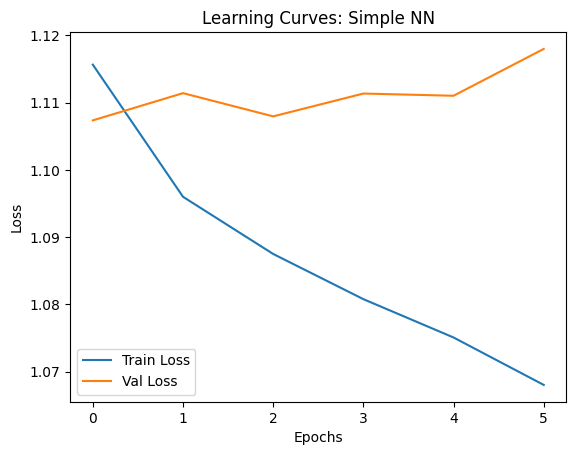

Simple NN Test Accuracy: 0.3485


In [8]:
# 2. Simple Model
print("Training Simple Model...")
simple_nn = build_simple_model(X_train.shape[1])
history_simple = train_with_early_stopping(simple_nn, X_train, y_train)
plot_curves(history_simple, "Simple NN")
print(f"Simple NN Test Accuracy: {simple_nn.evaluate(X_test, y_test, verbose=0)[1]:.4f}") # [cite: 28]

Training Dropout Model...


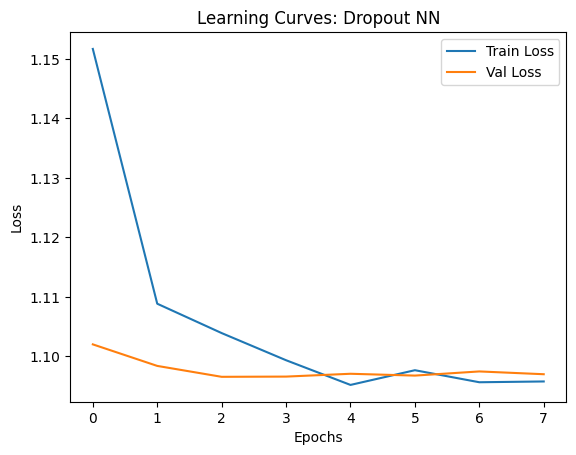

Dropout NN Test Accuracy: 0.3215


In [10]:
print("Training Dropout Model...")
dropout_nn = build_dropout_model(X_train.shape[1])
history_dropout = train_with_early_stopping(dropout_nn, X_train, y_train)
plot_curves(history_dropout, "Dropout NN")
print(f"Dropout NN Test Accuracy: {dropout_nn.evaluate(X_test, y_test, verbose=0)[1]:.4f}")

In [11]:
print("Performing 5-Fold Cross Validation...")
kf = KFold(n_splits=5)
scores = []
for train_idx, val_idx in kf.split(X):
    m = build_simple_model(X.shape[1])
    m.fit(X[train_idx], y[train_idx], epochs=10, batch_size=32, verbose=0)
    scores.append(m.evaluate(X[val_idx], y[val_idx], verbose=0)[1])
print(f"Average K-Fold Accuracy (Simple NN): {np.mean(scores):.4f}")


Performing 5-Fold Cross Validation...
Average K-Fold Accuracy (Simple NN): 0.3283


In [12]:
rf_model = RandomForestClassifier()
rf_scores = cross_val_score(rf_model, X, y, cv=5)
print(f"Scikit-learn (Random Forest) 5-Fold Accuracy: {np.mean(rf_scores):.4f}")

Scikit-learn (Random Forest) 5-Fold Accuracy: 0.3218
